In [1]:
# Imports
import json
import re

import matplotlib.pyplot as plt
from nltk.lm.preprocessing import flatten
import pandas as pd
import spacy
from spacy.tokens import Span

# Erstellung von CWI-Instanzen anhand von Paralleltexten

In diesem Notebook wird die Erstellung vom gelabelten Instanzen für CWI anhand von Paralleltexten durchgeführt. Dafür müssen zunächst alle benötigten Tools zur Vorverarbeitung bereitgestellt werden.

In [2]:
# Load spacy model
nlp = spacy.load("de_core_news_md")

# Load and prepare lemma dictionary for lemmatization
with open("data/lookups/de_lemma_lookup.json", encoding="utf-8") as file_in:
    lemma_dict = json.load(file_in)
    lemma_dict = lemma_dict | {v: v for v in lemma_dict.values()}

In [3]:
patterns = {
    # nominalizations
    r"^([A-Z].+)nden$": r"\1nde",
    r"^([A-Z].+)ens$": r"\1en",
    # nouns ending on -heit, -keit or -ung
    r"^([A-Z].+)([hk]eit|ung|schaft|ion)en$": r"\1\2",
    # adjectives
    r"^([a-z].+)(end|wert|lich|bar)e([rsn]?|re[rsn]?)$": r"\1\2",
    r"^([a-z]+)(isch)e([rsn]?|re[rsn]?)$": r"\1\2",
    # derived adjectives
    r"^(un)?(ver|zer|be|ge)(.+t)e([rsn]?|re[rsn]?)$": r"\1\2\3",
    # verbs
    r"^(ver|zer|be)(.+?)(ss)?(s?t|e)$": r"\1\2\3en"
}


def lemmatize(word):
    """Simple rule-based lemmatization using a dictionary and a couple of heuristics."""
    # First try lemmatization with dict
    if word in lemma_dict:
        return lemma_dict[word]
    # Fallback: use regular expressions
    for pattern, replacement in patterns.items():
        if re.match(pattern, word):
            return re.sub(pattern, replacement, word)
    return word


def reconstruct(word):
    """Sometimes explained word strings contain two versions separated by slash."""
    if "/" in word:
        word = word.split(" / ")[0]
    word = lemma_dict.get(word, lemmatize(word))
    return word.lower()


def prepare_text(text):
    """Prepare raw text by stripping unnecessary elements and whitespace."""
    text = re.sub(r"\n+[MDR|dpa|epd].*$", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


def get_span(tok):
    """Get the character span of the token"""
    span = Span(tok.doc, tok.i, tok.i+1)
    start = span.start_char - tok.sent.start_char
    end = span.end_char - tok.sent.start_char
    return start, end


def is_ent(tok):
    """Get entity type, if token is part of entity."""
    if tok.pos_ == "PUNCT":
        return ""
    return tok.ent_type_

Außerdem müssen die Texte geladen werden, welche zuvor über das [MDR-Archiv in Leichter Sprache](https://www.mdr.de/nachrichten-leicht/rueckblick/index.html) gesammelt wurden.

In [4]:
with open("data/mdr/mdr_texts_dec_mar.json", encoding="utf-8") as file_in:
    mdr_dict = json.load(file_in)


simple_texts = [v["simple_text"] for v in mdr_dict.values()]
orig_texts = [prepare_text(v["orig_text"]) for v in mdr_dict.values()]

simple_texts = simple_texts
orig_texts = orig_texts

print("Anzahl Leichter Texte:", len(simple_texts))
print("Anzahl komplexer Texte:", len(orig_texts))

Anzahl Leichter Texte: 274
Anzahl komplexer Texte: 274


Nun kann die Instanzgenerierung stattfinden. Bei der Extraktion der MDR-Daten wurden alle per Link zum Glossar erklärten Wörter im jeweiligen Text als Liste abgespeichert. Diese werden nun vorverarbeitet und in einem Set gespeichert: 

In [5]:
explained = list(set(flatten([v["explained_words"] for v in mdr_dict.values()])))
# Get explained words
orig_explained = set()
for word in explained:
    # Some of these strings contain " oder " or " / "
    # "Politiker oder Politikerin"
    # "vorgestellt / vorstellen"
    # -> Account for these possibilites
    if " oder " in word:
        words = word.split(" oder ")
        for w in words:
            orig_explained.add(reconstruct(w))
    else:
        orig_explained.add(reconstruct(word))

# A few examples...
list(orig_explained)[:5]

['zerstörung',
 'bundes-präsident',
 'raub-überfall',
 'kanal',
 'konzentrations-lager']

Außerdem muss ein Set an leichten Wörtern erstellt werden. Hierfür verwende ich alle Wörter, die in den Texten in Leichter Sprache auftreten, abzüglich derer, die per Link zu einem Glossar-Eintrag erklärt werden.

In [6]:
# Get set of words in simple texts
simple_words = set(flatten([[lemmatize(t.text).lower() for t in nlp(text)] for text in simple_texts]))
simple_words_complete = simple_words - orig_explained  # Remove explained words
# A few examples...
list(simple_words_complete)[:5]

['vormittag', 'holocaust-gedenktag', 'diebstähle', 'ukraine', 'clingen']

Nun kann die Annotation vorgenommen werden. Dafür wird zunächst eine pandas.Series mit allen Tokens der Texte in schwerer Sprache erstellt. 

In [7]:
toks = pd.Series(flatten([[t for t  in nlp(text)] for text in orig_texts]))
toks

0         Sachsen-Anhalt
1                   will
2                    die
3             Lehrkräfte
4                     an
               ...      
106349               von
106350        Geldsorgen
106351         geplagten
106352        Hochschule
106353                 .
Length: 106354, dtype: object

Anhand dieser Serie an spacy-Tokens wird der Dataframe erstellt. Neben dem jeweiligen Satz, der Target-Span und dem Label als zwingend notwendige Information für CWI werden ein paar weitere potenziell interessante Eigenschaften hinzugefügt. Dies umfasst:

- POS-Tag
- Art der Entität, wenn es sich um eine solche handelt

Diese Information kann anschließend genutzt werden, um die Daten vorab ein wenig zu filtern, also etwa Eigennamen von Personen zu entfernen, und Interpunktionszeichen einheitlich zu annotieren. Hilfreich wäre auch, Eigennamen, die Orte und Organisationen bezeichnen, auszuschließen, dies ist jedoch mit spacy als einzigem Mittel der Vorverarbeitung nicht präzise möglich.

In [8]:
# Get pd.Series for all necessary and additional information
sents = toks.apply(lambda x: x.sent.text)
pos = toks.apply(lambda x: x.pos_)
span_starts = toks.apply(lambda x: get_span(x)[0])
span_ends = toks.apply(lambda x: get_span(x)[1])
ent_type = toks.apply(is_ent)
target_strings = toks.apply(str)
# Get label: 1 if word is not in simple words set
annotation = target_strings.apply(lambda x: int(lemmatize(x).lower() not in simple_words_complete))

# Create dataframe from Series
annotation_df = pd.DataFrame({"sent": sents,
                   "target": target_strings,
                   "start": span_starts,
                   "end": span_ends,
                   "label": annotation,
                   "entity_type": ent_type,
                   "pos": pos})
# Filter data
# Remove people. People are strange.
annotation_df = annotation_df[annotation_df["entity_type"] != "PER"]
# Unify annotation for punctuation (to negative)
annotation_df["label"][annotation_df["pos"] == "PUNCT"] = 0
annotation_df = annotation_df.drop_duplicates()
annotation_df

,sent,target,start,end,label,entity_type,pos
0,Sachsen-Anhalt will die Lehrkräfte an Grundsch...,Sachsen-Anhalt,0,14,0,LOC,PROPN
1,Sachsen-Anhalt will die Lehrkräfte an Grundsch...,will,15,19,0,,AUX
2,Sachsen-Anhalt will die Lehrkräfte an Grundsch...,die,20,23,0,,DET
3,Sachsen-Anhalt will die Lehrkräfte an Grundsch...,Lehrkräfte,24,34,1,,NOUN
4,Sachsen-Anhalt will die Lehrkräfte an Grundsch...,an,35,37,0,,ADP
...,...,...,...,...,...,...,...
106349,Erfurter Studierende forderten zudem mehr Eins...,von,148,151,0,,ADP
106350,Erfurter Studierende forderten zudem mehr Eins...,Geldsorgen,152,162,1,,NOUN
106351,Erfurter Studierende forderten zudem mehr Eins...,geplagten,163,172,1,,ADJ
106352,Erfurter Studierende forderten zudem mehr Eins...,Hochschule,173,183,1,,NOUN


Hiermit erstellen wir nun ein Trainings-, Dev- und Testset. Die Größe ist natürlich skalierbar, zum der von mir implementierten Klassifikatoren setze ich zunächst 20.000 Trainingsinstanzen, 3.000 Dev-Instanzen und 3.000 Testinstanzen fest.

In [9]:
instance_df = annotation_df[-26000:]
train_df = instance_df[:20000]
dev_df = instance_df[20000:23000]
test_df = instance_df[23000:26000]

Nachfolgend sind einige Korpus-Statistiken aufgeführt:

In [10]:
print("---Trainingsdatensatz--------------------------")
print("Anzahl Instanzen:\t\t\t", len(train_df))
print("Anzahl positiver Instanzen (komplex):\t", len(train_df[train_df["label"] == 1]))
train_percentage = len(train_df[train_df["label"] == 1]) / len(train_df) * 100
print("In Prozent (%):\t\t\t\t", round(train_percentage, 2))

print()
print("---Development-Datensatz-----------------------")
print("Anzahl Instanzen:\t\t\t", len(dev_df))
print("Anzahl positiver Instanzen (komplex):\t", len(dev_df[dev_df["label"] == 1]))
dev_percentage = len(dev_df[dev_df["label"] == 1]) / len(dev_df) * 100
print("In Prozent (%):\t\t\t\t", round(dev_percentage, 2))

print()
print("---Testdatensatz-------------------------------")
print("Anzahl Instanzen:\t\t\t", len(test_df))
print("Anzahl positiver Instanzen (komplex):\t", len(test_df[test_df["label"] == 1]))
test_percentage = len(test_df[test_df["label"] == 1]) / len(test_df) * 100
print("In Prozent (%):\t\t\t\t", round(test_percentage, 2))

---Trainingsdatensatz--------------------------
Anzahl Instanzen:			 20000
Anzahl positiver Instanzen (komplex):	 5807
In Prozent (%):				 29.04

---Development-Datensatz-----------------------
Anzahl Instanzen:			 3000
Anzahl positiver Instanzen (komplex):	 918
In Prozent (%):				 30.6

---Testdatensatz-------------------------------
Anzahl Instanzen:			 3000
Anzahl positiver Instanzen (komplex):	 929
In Prozent (%):				 30.97


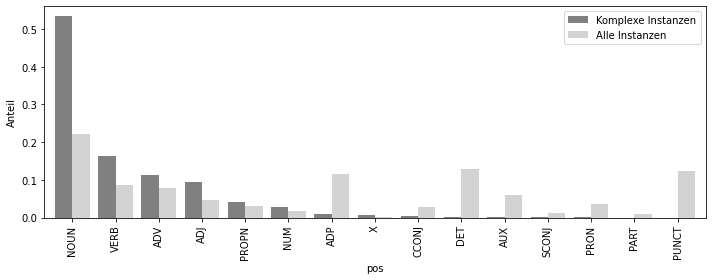

In [11]:
compl_df = instance_df[instance_df["label"] == 1]

pos_dist_df = pd.concat([compl_df.pos.value_counts(normalize=True),
                         instance_df.pos.value_counts(normalize=True)], axis=1)
pos_dist_df.fillna(0, inplace=True)
pos_dist_df.columns = ["positive instances", "all"]

pos_dist_df.plot.bar(
    color=["gray", "lightgray"],
    ylabel="Anteil",
    width=0.8,
    figsize=(10,4)
)
plt.legend(["Komplexe Instanzen", "Alle Instanzen"])
plt.tight_layout()